# Networks of persons in relation to organisations


Cf. [this notebook](https://github.com/Sciences-historiques-numeriques/histoire_numerique_methodes/blob/main/analyse_reseaux/reseaux_florence.ipynb) about families and power in Renaissance Florence for an introduction to network analysis with the *networkx* Python library



In [2]:
import pandas as pd


import networkx as nx
from networkx.algorithms import bipartite

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MaxNLocator

from scipy.stats import spearmanr
import statsmodels.api as sm

import numpy as np
import seaborn as sns
import math
import os

In [3]:
### this library allows to do SQL queries on dataframes
import duckdb

In [4]:
### Librairies déjà installées avec Python
import pprint
import csv

import sqlite3 as sql
import pickle

import time
import datetime
from dateutil import parser


from shutil import copyfile


In [5]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

import sys
from importlib import reload

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [6]:

import network_analysis_functions as naf
import bivariate_library as bl

In [7]:
print(reload(bl))  

<module 'bivariate_library' from '/home/francesco/kDrive/python_notebooks/astronomers/notebooks_jupyter/wikidata_exploration/../bivariate_library.py'>


In [8]:
import warnings
warnings.filterwarnings('ignore')


## Get and inspect the data


We use in this notebook the network data prepared in these two files:
* Get the [relationships with SPARQL](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da6-person-organisation-network.md)
* Prepare the [SQL view and export the data to CSV](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da6-person-organisation-network.sql)


Regarding persons, we reuse the file with the persons, their periods of activity and coded countries, that we created in the correspondence analysis chapter.




### Get the network data

In [9]:
### Import information about relations to organisations - df_po

csv_address='da_data/da6-persons-organisations-relations.csv'
df_po = pd.read_csv(csv_address)
df_po.head(3)

,person_uri,organisation_uri,organisation_label,relationship
0,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q153978,University of Tübingen,education
1,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q543804,German Academy of Sciences Leopoldina,membership
2,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q833738,Heidelberg Academy of Sciences and Humanities,membership


In [10]:
### Inspect the dataframe and 
# notably if there are missing values
df_po.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80676 entries, 0 to 80675
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   person_uri          80676 non-null  object
 1   organisation_uri    80676 non-null  object
 2   organisation_label  80676 non-null  object
 3   relationship        80676 non-null  object
dtypes: object(4)
memory usage: 2.5+ MB


In [11]:
### Number of types of relationships
df_rela_type=pd.DataFrame(df_po.groupby(by='relationship').size())
df_rela_type.columns=['number']
df_rela_type

,number
relationship,
education,29936
employment,32262
membership,18478


### Get the data about persons

#### First: get the individuals (20000) used for correspondence analysis 


In [12]:
### Information about persons with gender, birth date,
# coded country, etc.
csv_address='da_data/da4-AFC.csv'
### csv_address='da_data/da2-birth-place.csv'
df_p_AFC = pd.read_csv(csv_address)
df_p_AFC.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,France,1831,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,Germany,1827,1826-1850
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.033056 48.139722),http://www.wikidata.org/entity/Q752334,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1834,1826-1850


In [13]:
df_p_AFC=df_p_AFC[['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'REGION', 'NAME_ENGL', 'coded_country', 'periodsActivity']]

In [14]:
### Rename columns to have shorter labels
df_p_AFC.columns=['person_uri',
 'labelPer',
 'birthYear',
 'gender',
 'labelPlace',
 'REGION',
 'NAME_ENGL',
 'country',
 'per_activ'
 ]

In [15]:
### Inspect the dataframe and 
# notably if there are missing values
df_p_AFC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20043 entries, 0 to 20042
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   person_uri  20043 non-null  object
 1   labelPer    20043 non-null  object
 2   birthYear   20043 non-null  int64 
 3   gender      20043 non-null  object
 4   labelPlace  20043 non-null  object
 5   REGION      20043 non-null  object
 6   NAME_ENGL   20043 non-null  object
 7   country     20043 non-null  object
 8   per_activ   20043 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.4+ MB


#### Second: get the individuals (8000) used for clustering


In [16]:
file_address='da_data/da5-MCA-clusters.csv'
df_p_MCA = pd.read_csv(file_address)
df_p_MCA.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_main,occupation_sec1,coded_employer
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),Western Europe,France,France,1826-1850,27877,astronomer,mathematician,agency
1,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1781,male,Stadthagen,POINT (9.206944 52.324722),Western Europe,Germany,Germany,1826-1850,20217,physicist,chemist,university
2,http://www.wikidata.org/entity/Q5598801,Jonas Brag,1781,male,Göteborg City,POINT (11.965228 57.704581),Northern Europe,Sweden,Scandinavia,1826-1850,23593,astronomer,other,agency


In [17]:
### Rename columns to have shorter labels
df_p_MCA.columns=['person_uri',
 'labelPer',
 'birthYear',
 'gender',
 'labelPlace',
 'geometry',
 'REGION',
 'NAME_ENGL',
 'country',
 'per_activ',
 'pk_person_features',
 'occup_m',
 'occup_s',
 'empl']

In [18]:
df_p_MCA=df_p_MCA[['person_uri',
 'occup_m',
 'occup_s',
 'empl']
]

In [19]:
### Inspect the dataframe and 
# notably if there are missing values
df_p_MCA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7946 entries, 0 to 7945
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   person_uri  7946 non-null   object
 1   occup_m     7946 non-null   object
 2   occup_s     7946 non-null   object
 3   empl        7946 non-null   object
dtypes: object(4)
memory usage: 248.4+ KB


#### Third: add the additional NCA features to the first dataframe

In [20]:
df_p=df_p_AFC.merge(df_p_MCA, left_on=['person_uri'], right_on=['person_uri'], how='left')
df_p=df_p.fillna('')

In [21]:
print(len(df_p))
df_p.iloc[:3]

20043


,person_uri,labelPer,birthYear,gender,labelPlace,REGION,NAME_ENGL,country,per_activ,occup_m,occup_s,empl
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,Western Europe,France,France,1826-1850,astronomer,mathematician,agency
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,Western Europe,Germany,Germany,1826-1850,,,
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,Eastern Europe,Ukraine,Ukraine,1826-1850,,,


We can observe the limits a restriction to persons that only have the additional features: 

if we restrict to persons with MCA features, Albert Einstein would not be taken into account in the analysis of the network!

We cannot proceed with adding insights from clustering to the network: additional information should be first added to our information system.

We could just add the main occupation, with additional preparation (not yet implemented).


In [22]:
### Find Albert Einstein
duckdb.query("""
select *
from df_p
where labelPer like '%Einst%'
""").to_df()

,person_uri,labelPer,birthYear,gender,labelPlace,REGION,NAME_ENGL,country,per_activ,occup_m,occup_s,empl
0,http://www.wikidata.org/entity/Q937,Albert Einstein,1879,male,Ulm,Western Europe,Germany,Germany,1901-1925,,,
1,http://www.wikidata.org/entity/Q123371,Hans Albert Einstein,1904,male,Bern,Western Europe,Switzerland,Switzerland,1926-1950,physicist,university-teacher,education
2,http://www.wikidata.org/entity/Q824855,Bernhard Caesar Einstein,1930,male,Dortmund,Western Europe,Germany,Germany,1951-1975,,,


## Inspect the features of the relationships

### Distribution of relationships per country

#### Writing SQL queries with the duckdb library

In [23]:
### Distribution of coded countries
# using the duckdb library and a SQL query

# the result is the same as in the cell below
dfc=duckdb.query("""
    SELECT country, COUNT(*) as num
    FROM df_p
    GROUP BY country
    ORDER BY num DESC
  """).to_df()
dfc

,country,num
0,Germany,3158
1,United States Can.,2769
2,Russian Federation,2458
3,Italy,1128
4,United Kingdom,1120
5,France,1115
6,Czechia,1005
7,Poland,990
8,Austria Hungary,875
9,Baltic States Fin. Belar.,866


In [24]:
### Distribution of coded countries
dfc=pd.DataFrame(df_p.groupby(by=['country']).size())
dfc.sort_values(by=0,ascending=False)


,0
country,
Germany,3158
United States Can.,2769
Russian Federation,2458
Italy,1128
United Kingdom,1120
France,1115
Czechia,1005
Poland,990
Austria Hungary,875


## Merge the two dataframes

This will restrict the information about relations to the persons that are present in the file with the individuals (*da4-AFC.csv* with additional information from *da5-MCA-clusters.csv*)

In [25]:
df_p=df_p[['person_uri', 'labelPer', 'gender', 'birthYear','country', 'per_activ']]
df_p.head(3)

,person_uri,labelPer,gender,birthYear,country,per_activ
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,male,1786,France,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,male,1782,Germany,1826-1850
2,http://www.wikidata.org/entity/Q874465,József Csorba,male,1789,Ukraine,1826-1850


In [26]:
### Merge the two dataframes:
# only relations that involve persons in df_p
# will remain
df_rel=df_po.merge(df_p,on='person_uri')
print(len(df_rel))
df_rel.head(2)

58358


,person_uri,organisation_uri,organisation_label,relationship,labelPer,gender,birthYear,country,per_activ
0,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q153978,University of Tübingen,education,Hans Elsässer,male,1929,Germany,1951-1975
1,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q543804,German Academy of Sciences Leopoldina,membership,Hans Elsässer,male,1929,Germany,1951-1975


### Inspect the merge result

In [27]:
### Unique persons
unique_p=pd.DataFrame(df_rel['person_uri'].unique())
unique_p.columns=['person_uri']
len_up=len(unique_p)
print(f"Number of persons with relations: {len_up}")
unique_p.head(2)

Number of persons with relations: 16416


,person_uri
0,http://www.wikidata.org/entity/Q1000193
1,http://www.wikidata.org/entity/Q1000934


In [28]:
### Number of types of relationships and per person proportion
df_rela_type=pd.DataFrame(df_rel.groupby(by='relationship').size())
df_rela_type.columns=['number']
df_rela_type['propr_rela_per_person']=df_rela_type['number'].apply(lambda x : x/len_up)
df_rela_type

,number,propr_rela_per_person
relationship,,
education,20843,1.269676
employment,22636,1.378899
membership,14879,0.906372


### Restriction to persons with memberships

We observe from the former queries, that some persons have no memberships. 

In our analysis of the field, notably with a question about correlation  we decide 


In [29]:
###  Count number of relations per person
df_rel = duckdb.query("""
    with tw1 AS (
    -- we create a list of persons with memberships
    SELECT DISTINCT person_uri
    FROM df_rel
    WHERE relationship='membership'
    )
    SELECT *
    FROM df_rel 
    WHERE person_uri IN (SELECT person_uri FROM tw1)
    
""").to_df()
print(len(df_rel))
df_rel.iloc[:2]

35768


,person_uri,organisation_uri,organisation_label,relationship,labelPer,gender,birthYear,country,per_activ
0,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q153978,University of Tübingen,education,Hans Elsässer,male,1929,Germany,1951-1975
1,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q543804,German Academy of Sciences Leopoldina,membership,Hans Elsässer,male,1929,Germany,1951-1975


In [30]:
###  Count number of relations per person
duckdb.query("""
    WITH tw1 AS (
    -- we create a list of unique persons
    SELECT DISTINCT person_uri
    FROM df_rel
    )
    SELECT relationship, COUNT(*) as number, 
            ROUND(COUNT(*)/(SELECT COUNT(*) FROM tw1),2) AS propr_rela_per_person
    FROM df_rel 
    GROUP BY relationship
    ORDER BY relationship    
""").to_df()

,relationship,number,propr_rela_per_person
0,education,9721,1.42
1,employment,11168,1.63
2,membership,14879,2.18


### Number of relationships per person

In [31]:
###  Count number of relations per person
print('Number of relations per person:')
df_pn = duckdb.query("""
    with tw1 AS (
    SELECT person_uri, COUNT(*) as number
    FROM df_rel
    GROUP BY person_uri
    )
    SELECT labelPer,number, birthYear,country,per_activ, tw1.person_uri
    from tw1 join df_p on df_p.person_uri = tw1.person_uri
    ORDER BY number DESC
""").to_df()
df_pn.iloc[:8]

Number of relations per person:


,labelPer,number,birthYear,country,per_activ,person_uri
0,Albert Einstein,37,1879,Germany,1901-1925,http://www.wikidata.org/entity/Q937
1,Theodore von Kármán,36,1881,Austria Hungary,1926-1950,http://www.wikidata.org/entity/Q164384
2,Hermann von Helmholtz,32,1821,Germany,1851-1875,http://www.wikidata.org/entity/Q60024
3,Henri Poincaré,29,1854,France,1876-1900,http://www.wikidata.org/entity/Q81082
4,Max Planck,29,1858,Germany,1901-1925,http://www.wikidata.org/entity/Q9021
5,Peter Debye,29,1884,Belgium Netherl.,1926-1950,http://www.wikidata.org/entity/Q103835
6,Niels Bohr,28,1885,Scandinavia,1926-1950,http://www.wikidata.org/entity/Q7085
7,Max von Laue,27,1879,Germany,1901-1925,http://www.wikidata.org/entity/Q57067


In [32]:
### Statistical profile
print(df_pn.number.describe())

count    6832.000000
mean        5.235363
std         3.573794
min         1.000000
25%         3.000000
50%         4.000000
75%         7.000000
max        37.000000
Name: number, dtype: float64


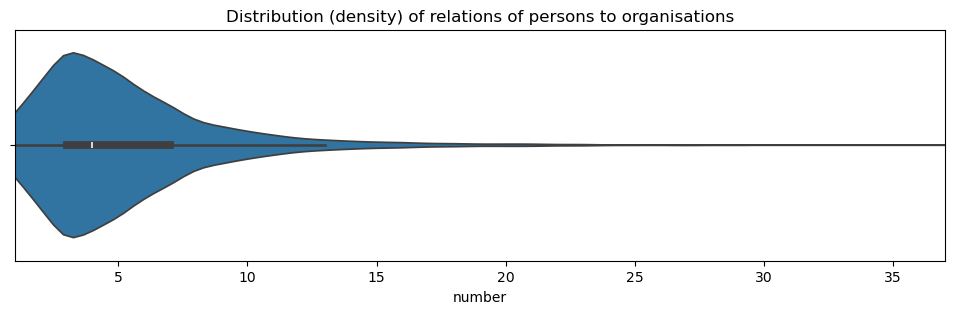

In [33]:
# Plot the distribution number of relations to organisations

min_val = df_pn.number.min()
max_val = df_pn.number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df_pn.number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

### Inspect the persons with a high number of relationships

In [34]:
### Persons that have 10 or more relations to organisations
print(len(df_pn[df_pn.number > 9]))

680


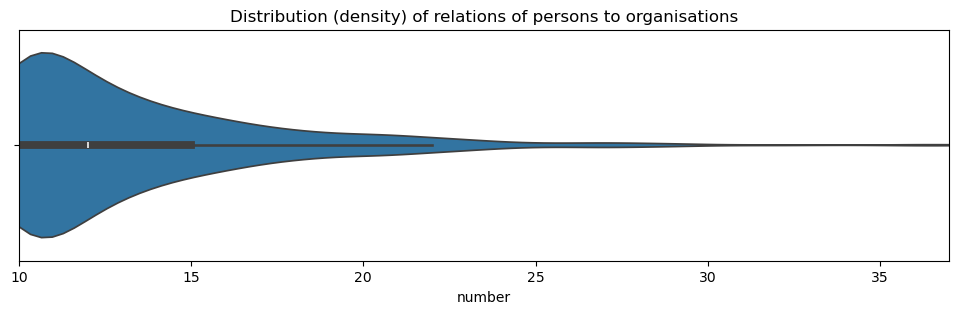

In [35]:
# Plot the distribution number of relations to organisations

df=df_pn[df_pn.number > 9]

min_val = df.number.min()
max_val = df.number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

In [36]:
### Number of types of relationships, all the persons
df_rela_type=pd.DataFrame(df_rel.groupby(by='relationship').size())
df_rela_type.columns=['number']

### Type of relationship of the 700 more connected persons (merge on the fly)
df_pn[df_pn.number > 9].merge(df_rel, left_on='person_uri', right_on='person_uri').groupby(by='relationship').size()

df_rela_type=df_rela_type.join((df_pn[df_pn.number > 9].\
                   merge(df_rel, left_on='person_uri', right_on='person_uri').groupby(by='relationship').size()).rename('rel_700'))

### Add the proportion between all the relations and those of the most connected persons
df_rela_type['prop']=df_rela_type.apply(lambda x: x['rel_700']/x['number'], axis=1)
### We observe that memberships are overrepresented for this very well known persons
df_rela_type


,number,rel_700,prop
relationship,,,
education,9721,1833,0.188561
employment,11168,2662,0.238360
membership,14879,4601,0.309228


## Relationships with organisations in relation to activity periods

Observe if periods are specific to relations and which ones 

In [37]:
### Distribution of RELATIONS by periods of activity
activities_per = pd.DataFrame(df_rel.groupby(by='per_activ').size())
activities_per.columns=['number_rel']
print(activities_per)

           number_rel
per_activ            
1826-1850        1330
1851-1875        1427
1876-1900        2348
1901-1925        2859
1926-1950        4791
1951-1975        8528
1976-2000       10335
2001-2025        4150


In [38]:
### Distribution of PERSONS by periods of activity
period_per = pd.DataFrame(df_p.groupby(by='per_activ').size())
period_per.columns=['number_per']
print(period_per)

           number_per
per_activ            
1826-1850         395
1851-1875         559
1876-1900         913
1901-1925        1416
1926-1950        2215
1951-1975        4695
1976-2000        6675
2001-2025        3175


In [39]:
df_ap_per=activities_per.join(period_per)

### Number of activities divided by number of persons
df_ap_per['proportion']=df_ap_per.apply(lambda x: x.number_rel/x.number_per, axis=1).round(3)
df_ap_per

,number_rel,number_per,proportion
per_activ,,,
1826-1850,1330,395,3.367
1851-1875,1427,559,2.553
1876-1900,2348,913,2.572
1901-1925,2859,1416,2.019
1926-1950,4791,2215,2.163
1951-1975,8528,4695,1.816
1976-2000,10335,6675,1.548
2001-2025,4150,3175,1.307


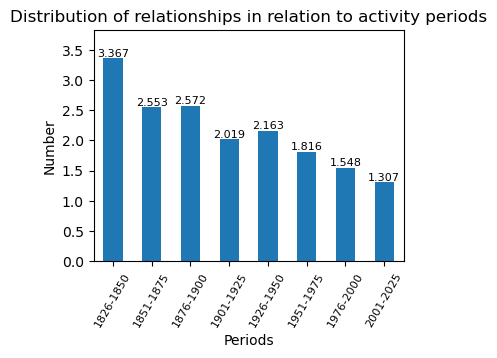

In [40]:
### Plot the evolution in time


ax = df_ap_per.proportion.plot(kind='bar',rot=50, fontsize=10, figsize=(4,3))
ax.bar_label(ax.containers[-1], size=8)


current_min, current_max = ax.get_ylim()
ax.set_ylim(current_min, current_max+0.3)

# Rotate labels 60 degrees and reduce font size
plt.xticks(rotation=60, fontsize=8)

plt.ylabel('Number')
plt.xlabel('Periods')
plt.title('Distribution of relationships in relation to activity periods')
plt.show()

In [41]:
### Create a cross-table
crosstab = pd.crosstab(df_rel['per_activ'],df_rel['relationship'])
# Optional: Remove the index name if you want a cleaner look
# crosstab.index.name = None
crosstab.columns.name = None
crosstab


,education,employment,membership
per_activ,,,
1826-1850,250,274,806
1851-1875,318,333,776
1876-1900,610,591,1147
1901-1925,771,849,1239
1926-1950,1251,1597,1943
1951-1975,2366,2668,3494
1976-2000,2887,3360,4088
2001-2025,1268,1496,1386


In [42]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: True


In [43]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 503.06 , dof : 14
p-value : 0.0
Inertia (Phi-square):  0.014
Cramer:  0.084


#### Comment

A relation appears between type of relationship and period, but it is weak. As we can observe in the heatmap of adjusted residuals: membership tends to be proportionally more present in the 19th century, while study and employment are more present in the 20th century. 

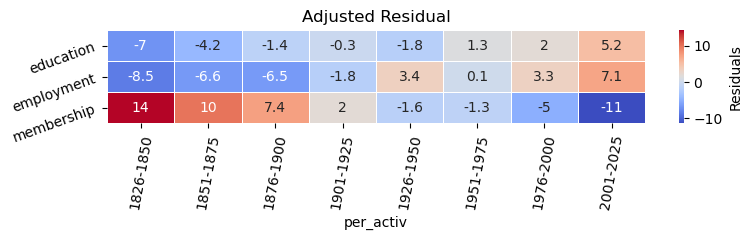

In [44]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 2.5))

## Relationships with organisations in relation to periods: analysis per relationship type

### Universities - education

In [45]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='education']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['per_activ'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

In [46]:
### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
## We take only the 20 organisations with more relationships
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct


Number of persons per organisation and period: 1990


per_activ,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025,sum
Harvard University,0,5,8,15,20,52,83,26,209
University of Cambridge,1,1,8,17,41,48,50,21,187
Massachusetts Institute of Technology,0,0,0,8,14,50,61,33,166
University of Göttingen,7,10,18,18,42,34,12,6,147
"University of California, Berkeley",0,0,0,3,11,53,53,21,141
California Institute of Technology,0,0,0,0,7,47,59,16,129
Princeton University,0,0,0,3,16,30,43,30,122
Humboldt-Universität zu Berlin,7,11,20,35,32,14,2,1,122
École Normale Supérieure,0,10,15,22,14,20,27,13,121
Lomonosov Moscow State University,0,0,2,5,14,44,41,6,112


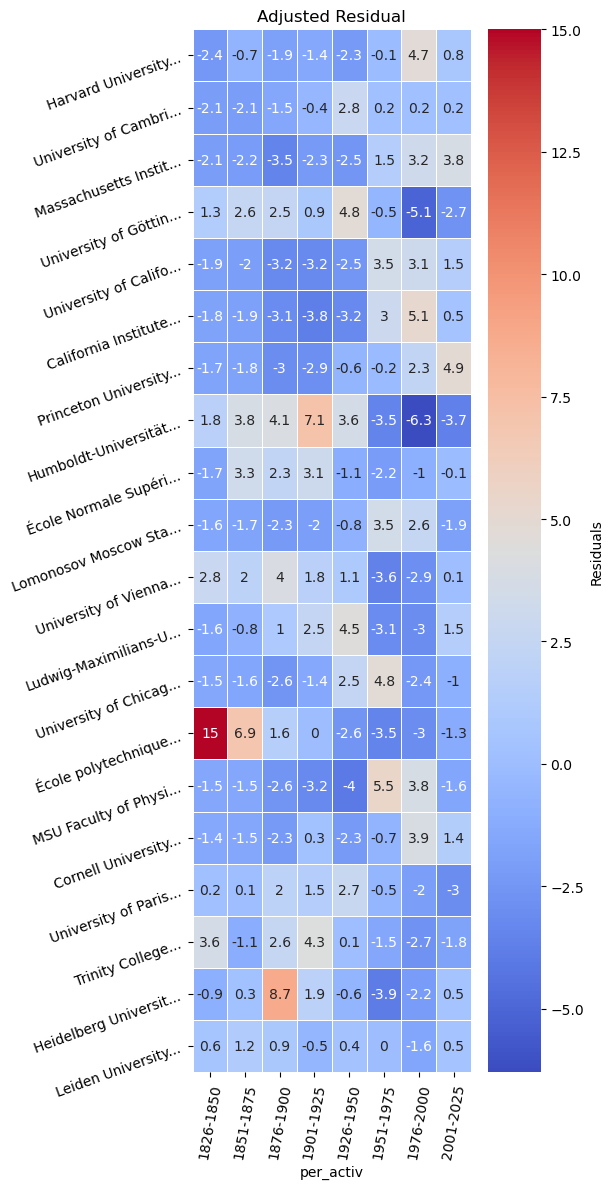

In [47]:
### Specific periods with the residuals heatmap on the corrtable
cct.index=[e[:20]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,12))

### Employers

In [48]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='employment']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['per_activ'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct

Number of persons per organisation and period: 2411


per_activ,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025,sum
Harvard University,1,5,6,11,27,50,62,18,180
Massachusetts Institute of Technology,1,0,3,6,24,53,42,16,145
"University of California, Berkeley",0,2,0,4,11,44,59,16,136
Princeton University,1,1,2,6,12,27,46,15,110
University of Cambridge,4,1,9,10,22,31,22,9,108
Leiden University,2,2,4,8,14,32,31,15,108
California Institute of Technology,0,0,0,2,13,39,35,18,107
Lomonosov Moscow State University,1,0,3,11,25,41,23,1,105
University of Chicago,0,0,3,11,19,33,20,13,99
University of Göttingen,1,6,11,21,31,17,8,4,99


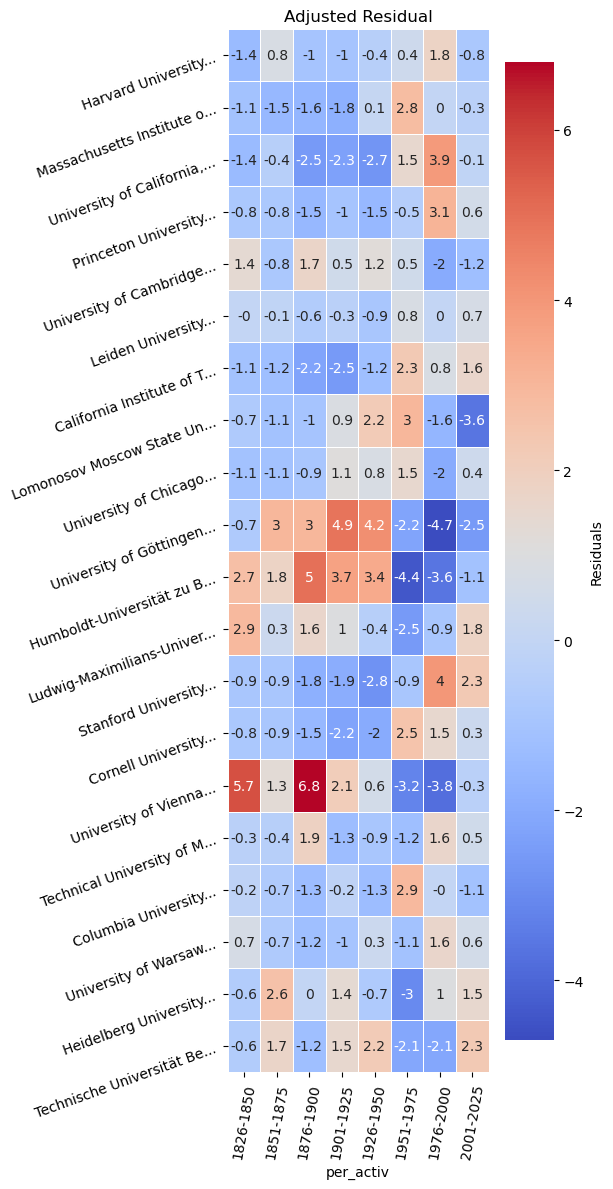

In [49]:
cct.index=[e[:25]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,12))

### Memberships

In [50]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='membership']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['per_activ'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct

Number of persons per organisation and period: 1293


per_activ,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025,sum
American Academy of Arts and Sciences,42,48,57,75,134,345,308,81,1090
National Academy of Sciences,12,35,59,73,138,342,319,84,1062
International Astronomical Union,0,0,4,8,24,67,422,342,867
Royal Society,76,65,86,74,107,197,153,30,788
German Academy of Sciences Leopoldina,35,41,108,76,91,116,86,55,608
Russian Academy of Sciences,30,28,38,52,89,180,162,12,591
French Academy of Sciences,44,37,42,44,46,70,84,14,381
Academia Europaea,0,0,0,0,0,74,236,68,378
Accademia Nazionale dei Lincei,17,43,69,59,49,65,50,15,367
American Philosophical Society,10,15,34,58,80,115,34,1,347


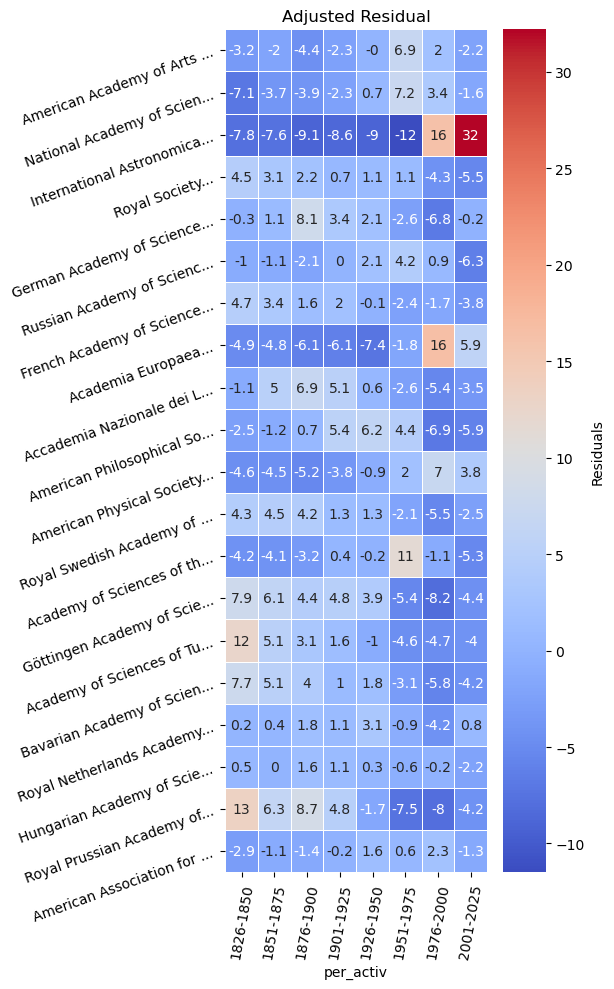

In [51]:
cct.index=[e[:25]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,10))

## Add years to approximate possible relations


In this exercice we artificially build relationships between persons without providing a measure of their real match to reality. In a heuristic perspective, the aim is just to have a consistent network in view of applying some analysis techniques.


We model artificial or imputed encounters based on the idea that persons present in the same institutions in the same period virtually know each other. But this is not alway the case although it allows to build person networks around organisations.

In [52]:
### fonction that codes the year of begin of an 'encounter'
def code_year_begin(type_relation, year):
    if type_relation=='education':
        begin=int(year)+20
    elif type_relation=='employment':
        begin=int(year)+28
    elif type_relation=='membership':
        begin=int(year)+40
    else :
        begin = 0

    return begin    

In [53]:
### function that codes the year of end of the virtual "encounter"
def code_year_end(type_relation, year):
    if type_relation=='education':
        end=int(year)+28
    elif type_relation=='employment':
        end=int(year)+65
    elif type_relation=='membership':
        end=int(year)+65
    else :
        end = 0
        
    return end

In [54]:
### Apply the functions 
df_rel['year_begin'] = df_rel.apply(lambda x : code_year_begin(x['relationship'], x['birthYear']), axis=1)
df_rel['year_end'] = df_rel.apply(lambda x : code_year_end(x['relationship'], x['birthYear']), axis=1)

In [55]:
### Inspect the coding
df_rel[df_rel.relationship=='membership'].iloc[10:15]

,person_uri,organisation_uri,organisation_label,relationship,labelPer,gender,birthYear,country,per_activ,year_begin,year_end
25,http://www.wikidata.org/entity/Q1002250,http://www.wikidata.org/entity/Q463303,American Academy of Arts and Sciences,membership,Duncan Haldane,male,1951,United Kingdom,1976-2000,1991,2016
26,http://www.wikidata.org/entity/Q1002250,http://www.wikidata.org/entity/Q466113,American Physical Society,membership,Duncan Haldane,male,1951,United Kingdom,1976-2000,1991,2016
27,http://www.wikidata.org/entity/Q1002250,http://www.wikidata.org/entity/Q513283,Institute of Physics,membership,Duncan Haldane,male,1951,United Kingdom,1976-2000,1991,2016
31,http://www.wikidata.org/entity/Q100235232,http://www.wikidata.org/entity/Q337352,The World Academy of Sciences,membership,Joseph Johnson III,male,1940,United States Can.,1976-2000,1980,2005
35,http://www.wikidata.org/entity/Q100276765,http://www.wikidata.org/entity/Q2985434,Comité des Travaux Historiques et Scientifiques,membership,Charles-Henri Tabareau,male,1790,France,1826-1850,1830,1855


## Create pairs of persons: education

Create relations of persons through relations to organisations

In [56]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='education'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'per_activ']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

9721


In [57]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_edu = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_edu))

444613


In [58]:
### Inspect
merged_edu.head(2)

,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q153978,University of Tübingen,1949,1957,1951-1975,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1949,1957,1951-1975
1,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q153978,University of Tübingen,1949,1957,1951-1975,http://www.wikidata.org/entity/Q112961,Otto Haxel,1929,1937,1951-1975


In [59]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_edu = merged_edu[merged_edu['person_uri_x'] < (merged_edu['person_uri_y'])]
print(len(merged_edu), '-', len(merged_edu)*2)

217446 - 434892


In [60]:
### Restrict time overlap (allow only 7 years overlap) — could be extended to have a larger result

# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_edu = merged_edu[(merged_edu['year_begin_y'] < merged_edu['year_end_x']) & (merged_edu['year_begin_x'] < merged_edu['year_end_y'])]
print(len(merged_edu))

## We observe that linked people are not necessarily in the same activity period
merged_edu.head(3)


33833


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
12,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q153978,University of Tübingen,1949,1957,1951-1975,http://www.wikidata.org/entity/Q4898262,Betsy Ancker-Johnson,1947,1955,1951-1975
33,http://www.wikidata.org/entity/Q100155322,Edgar Knobloch,http://www.wikidata.org/entity/Q13371,Harvard University,1973,1981,1976-2000,http://www.wikidata.org/entity/Q106949,Saul Perlmutter,1979,1987,2001-2025
41,http://www.wikidata.org/entity/Q100155322,Edgar Knobloch,http://www.wikidata.org/entity/Q13371,Harvard University,1973,1981,1976-2000,http://www.wikidata.org/entity/Q1173616,David B. Kaplan,1978,1986,2001-2025


In [61]:
### Number of educational relations per university 
gbe_edu = duckdb.query("""
    
    SELECT organisation_label, COUNT(*) as number
    FROM merged_edu
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_edu.iloc[:10]

,organisation_label,number
0,Harvard University,3317
1,Massachusetts Institute of Technology,2392
2,University of Cambridge,2197
3,"University of California, Berkeley",1856
4,California Institute of Technology,1739
5,MSU Faculty of Physics,1337
6,Lomonosov Moscow State University,1279
7,Princeton University,1238
8,University of Göttingen,1126
9,University of Chicago,1003


### Aggregate relationships during studies

#### Example of connected persons

Displayed with **Allegrograph Gruff**

<img src="images/alg_gruff_example_chinese_connected_education.png" alt="drawing" width="700"/>

In [73]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_edu = merged_edu.groupby(by=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'per_activ_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_edu['number'] = gr_edu.organisation_label.apply(lambda x : len(x.split('|')))

print('Length Edu Network:', len(gr_edu))


Length Edu Network: 33071


In [74]:
gr_edu=gr_edu.reset_index()
gr_edu.sort_values(by='number', ascending=False).head()

,person_uri_x,person_uri_y,per_activ_x,year_begin_x,year_end_x,year_begin_y,year_end_y,per_activ_y,organisation_label,organisation_uri,number
15098,http://www.wikidata.org/entity/Q181369,http://www.wikidata.org/entity/Q183679,1951-1975,1942,1950,1946,1954,1951-1975,National Southwestern Associated University|Na...,http://www.wikidata.org/entity/Q519556|http://...,5
32225,http://www.wikidata.org/entity/Q742536,http://www.wikidata.org/entity/Q9095,1876-1900,1851,1859,1851,1859,1876-1900,University of Edinburgh|Edinburgh Academy|Univ...,http://www.wikidata.org/entity/Q160302|http://...,4
30623,http://www.wikidata.org/entity/Q60264,http://www.wikidata.org/entity/Q61686,1926-1950,1901,1909,1902,1910,1926-1950,Technische Universität Berlin|Technical Univer...,http://www.wikidata.org/entity/Q51985|http://w...,3
10631,http://www.wikidata.org/entity/Q153238,http://www.wikidata.org/entity/Q155786,1926-1950,1918,1926,1920,1928,1926-1950,Budapest University of Technology and Economic...,http://www.wikidata.org/entity/Q1186843|http:/...,3
12657,http://www.wikidata.org/entity/Q1627897,http://www.wikidata.org/entity/Q47285,1876-1900,1869,1877,1876,1884,1901-1925,Victoria University of Manchester|Trinity Coll...,http://www.wikidata.org/entity/Q867530|http://...,3


In [75]:
### change columns names
gr_edu.columns=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'per_activ_y', 'orgs_labels', 'orgs_uris', 'orgs_number']
### change columns positions
gr_edu = gr_edu[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'per_activ_x',  'per_activ_y']]
gr_edu.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
15098,http://www.wikidata.org/entity/Q181369,http://www.wikidata.org/entity/Q183679,National Southwestern Associated University|Na...,5,http://www.wikidata.org/entity/Q519556|http://...,1951-1975,1951-1975
32225,http://www.wikidata.org/entity/Q742536,http://www.wikidata.org/entity/Q9095,University of Edinburgh|Edinburgh Academy|Univ...,4,http://www.wikidata.org/entity/Q160302|http://...,1876-1900,1876-1900


In [76]:
### The overwhelming majority of the population has only one study relationship
print('More then 2 relations:', len(gr_edu[gr_edu.orgs_number>2]), '\n2 relations:', len(gr_edu[gr_edu.orgs_number==2]),
      '\none relation:', len(gr_edu[gr_edu.orgs_number==1]))

More then 2 relations: 10 
2 relations: 739 
one relation: 32322


In [77]:
### Find persons in different periods

# Related persons can belong to different periods

## We observe that there is significant overlap: 
## These people and pairs represent BRIDGES between periods !

print(len(gr_edu[gr_edu.per_activ_x != gr_edu.per_activ_y]))
gr_edu[gr_edu.per_activ_x != gr_edu.per_activ_y].sort_values(by='orgs_number', ascending=False).iloc[:5]

5390


,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
12657,http://www.wikidata.org/entity/Q1627897,http://www.wikidata.org/entity/Q47285,Victoria University of Manchester|Trinity Coll...,3,http://www.wikidata.org/entity/Q867530|http://...,1876-1900,1901-1925
29978,http://www.wikidata.org/entity/Q57067,http://www.wikidata.org/entity/Q60264,Humboldt-Universität zu Berlin|University of G...,3,http://www.wikidata.org/entity/Q152087|http://...,1901-1925,1926-1950
3143,http://www.wikidata.org/entity/Q110968,http://www.wikidata.org/entity/Q262807,Leiden University|University of Amsterdam,2,http://www.wikidata.org/entity/Q156598|http://...,1951-1975,1926-1950
24412,http://www.wikidata.org/entity/Q3371831,http://www.wikidata.org/entity/Q523702,Free University of Brussels|Université libre d...,2,http://www.wikidata.org/entity/Q20754971|http:...,1951-1975,1976-2000
8106,http://www.wikidata.org/entity/Q1351105,http://www.wikidata.org/entity/Q3218144,California Institute of Technology|Cornell Uni...,2,http://www.wikidata.org/entity/Q161562|http://...,2001-2025,1976-2000


## Create pairs of persons: employment


Create relations of persons through relations to organisations

In [78]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='employment'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'per_activ']].copy(deep=True)
### Order by person_uri
# df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

11168


In [79]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_empl = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_empl))


360050


In [80]:
merged_empl.head(2)

,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
0,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,http://www.wikidata.org/entity/Q161562,California Institute of Technology,1920,1957,1926-1950,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1920,1957,1926-1950
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,http://www.wikidata.org/entity/Q161562,California Institute of Technology,1920,1957,1926-1950,http://www.wikidata.org/entity/Q102375173,Thomas G. Phillips,1965,2002,1976-2000


In [81]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_empl = merged_empl[merged_empl['person_uri_x'] < (merged_empl['person_uri_y'])]
print(len(merged_empl), '-', len(merged_empl)*2)

174441 - 348882


In [82]:
### Restrict time overlap : from 28 to 65
# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_empl = merged_empl[(merged_empl['year_begin_y'] < merged_empl['year_end_x']) & (merged_empl['year_begin_x'] < merged_empl['year_end_y'])]
print(len(merged_empl))

## We observe that linked people are not necessarily in the same activity period
merged_empl.head(3)


106694


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
3,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,http://www.wikidata.org/entity/Q161562,California Institute of Technology,1920,1957,1926-1950,http://www.wikidata.org/entity/Q111028460,John B. Irwin,1937,1974,1951-1975
5,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,http://www.wikidata.org/entity/Q161562,California Institute of Technology,1920,1957,1926-1950,http://www.wikidata.org/entity/Q115462,Fritz Zwicky,1926,1963,1926-1950
6,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,http://www.wikidata.org/entity/Q161562,California Institute of Technology,1920,1957,1926-1950,http://www.wikidata.org/entity/Q116786674,Marjorie Meinel,1950,1987,1951-1975


In [83]:
### Organisations with most frequent co-employments
gbe_empl = duckdb.query("""
    SELECT organisation_label, COUNT(*) as number
    FROM merged_empl
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_empl.iloc[:10]

,organisation_label,number
0,Harvard University,9192
1,Massachusetts Institute of Technology,7153
2,"University of California, Berkeley",6824
3,California Institute of Technology,4206
4,Princeton University,3973
5,Lomonosov Moscow State University,3801
6,Leiden University,3348
7,University of Chicago,2896
8,University of Cambridge,2827
9,University of Göttingen,2415


### Create network of persons relationships during emloyment

In [84]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_empl = merged_empl.groupby(by=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'per_activ_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_empl['number'] = gr_empl.organisation_label.apply(lambda x : len(x.split('|')))

print(len(gr_empl))


103160


In [85]:
gr_empl=gr_empl.reset_index()
gr_empl.sort_values(by='number', ascending=False).head(2)

,person_uri_x,person_uri_y,per_activ_x,year_begin_x,year_end_x,year_begin_y,year_end_y,per_activ_y,organisation_label,organisation_uri,number
67140,http://www.wikidata.org/entity/Q246497,http://www.wikidata.org/entity/Q707137,1951-1975,1939,1976,1928,1965,1926-1950,Lomonosov Moscow State University|Moscow Insti...,http://www.wikidata.org/entity/Q13164|http://w...,5
35383,http://www.wikidata.org/entity/Q1545341,http://www.wikidata.org/entity/Q193655,1926-1950,1927,1964,1927,1964,1926-1950,Harvard University|Leiden University|Universit...,http://www.wikidata.org/entity/Q13371|http://w...,4


In [86]:
### change columns names
gr_empl.columns=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'per_activ_y', 'orgs_labels', 'orgs_uris', 'orgs_number']
### change columns positions
gr_empl = gr_empl[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'per_activ_x', 'per_activ_y']]
gr_empl.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
67140,http://www.wikidata.org/entity/Q246497,http://www.wikidata.org/entity/Q707137,Lomonosov Moscow State University|Moscow Insti...,5,http://www.wikidata.org/entity/Q13164|http://w...,1951-1975,1926-1950
35383,http://www.wikidata.org/entity/Q1545341,http://www.wikidata.org/entity/Q193655,Harvard University|Leiden University|Universit...,4,http://www.wikidata.org/entity/Q13371|http://w...,1926-1950,1926-1950


In [87]:
### The overwhelming majority of the population has only one occupation relationship
print('More then 2 relations:', len(gr_empl[gr_empl.orgs_number>2]), 
      '\n2 relations:', len(gr_empl[gr_empl.orgs_number==2]),
      '\n1 relations:', len(gr_empl[gr_empl.orgs_number==1]))
print(f'Maximum number of relationships in employments: {gr_empl.orgs_number.max()}')

More then 2 relations: 183 
2 relations: 3150 
1 relations: 99827
Maximum number of relationships in employments: 5


## Create pairs of persons: membership

Create relations of persons through relations to organisations

In [88]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='membership'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'per_activ']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

14879


In [89]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_memb = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_memb))


5835807


In [90]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_memb = merged_memb[merged_memb['person_uri_x'] < (merged_memb['person_uri_y'])]
print(len(merged_memb), '-', len(merged_memb)*2)

2910464 - 5820928


In [91]:
### Restrict time overlap (allow only 7 years overlap) — could be extended to have a larger result

# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_memb = merged_memb[(merged_memb['year_begin_y'] < merged_memb['year_end_x']) & (merged_memb['year_begin_x'] < merged_memb['year_end_y'])]
print(len(merged_memb))

## We observe that linked people are not necessarily in the same activity period
merged_memb.head(3)


1240253


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
1,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q543804,German Academy of Sciences Leopoldina,1969,1994,1951-1975,http://www.wikidata.org/entity/Q100216,Willi Kalender,1989,2014,1976-2000
7,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q543804,German Academy of Sciences Leopoldina,1969,1994,1951-1975,http://www.wikidata.org/entity/Q102226864,Werner Känzig,1962,1987,1951-1975
10,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q543804,German Academy of Sciences Leopoldina,1969,1994,1951-1975,http://www.wikidata.org/entity/Q103854,Aage Bohr,1962,1987,1951-1975


In [92]:
### count membership relations by organisation
gbe_memb=duckdb.query("""
    SELECT organisation_label, COUNT(*) as number
    FROM merged_memb
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_memb.iloc[:10]

,organisation_label,number
0,International Astronomical Union,260033
1,National Academy of Sciences,237685
2,American Academy of Arts and Sciences,233831
3,Royal Society,88610
4,Russian Academy of Sciences,68782
5,Academia Europaea,56059
6,German Academy of Sciences Leopoldina,49414
7,American Physical Society,30390
8,Academy of Sciences of the USSR,24223
9,American Philosophical Society,23826


### Create network of persons relationships during membership

In [93]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_memb = merged_memb.groupby(by=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'per_activ_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_memb['number'] = gr_memb.organisation_label.apply(lambda x : len(x.split('|')))
gr_memb=gr_memb.reset_index()
print(len(gr_memb))


997706


In [94]:
### Inspect grouped membership relationships
gr_memb.sort_values(by='number', ascending=False).head()

,person_uri_x,person_uri_y,per_activ_x,year_begin_x,year_end_x,year_begin_y,year_end_y,per_activ_y,organisation_label,organisation_uri,number
830718,http://www.wikidata.org/entity/Q41688,http://www.wikidata.org/entity/Q81082,1876-1900,1893,1918,1894,1919,1876-1900,Göttingen Academy of Sciences and Humanities i...,http://www.wikidata.org/entity/Q414188|http://...,16
990806,http://www.wikidata.org/entity/Q81082,http://www.wikidata.org/entity/Q83297,1876-1900,1894,1919,1882,1907,1876-1900,Russian Academy of Sciences|Bavarian Academy o...,http://www.wikidata.org/entity/Q83172|http://w...,15
944039,http://www.wikidata.org/entity/Q60024,http://www.wikidata.org/entity/Q83297,1851-1875,1861,1886,1882,1907,1876-1900,Göttingen Academy of Sciences and Humanities i...,http://www.wikidata.org/entity/Q414188|http://...,14
974980,http://www.wikidata.org/entity/Q71031,http://www.wikidata.org/entity/Q8750,1851-1875,1851,1876,1831,1856,1826-1850,Bavarian Academy of Sciences and Humanities|Am...,http://www.wikidata.org/entity/Q684415|http://...,14
973131,http://www.wikidata.org/entity/Q7085,http://www.wikidata.org/entity/Q937,1926-1950,1925,1950,1919,1944,1901-1925,Accademia Nazionale delle Scienze detta dei XL...,http://www.wikidata.org/entity/Q3603946|http:/...,14


In [95]:
### change columns names
gr_memb.columns=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'per_activ_y', 'orgs_labels', 'orgs_uris', 'orgs_number']

In [96]:
### change columns positions
gr_memb = gr_memb[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'per_activ_x', 'per_activ_y']]
gr_memb.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
830718,http://www.wikidata.org/entity/Q41688,http://www.wikidata.org/entity/Q81082,Göttingen Academy of Sciences and Humanities i...,16,http://www.wikidata.org/entity/Q414188|http://...,1876-1900,1876-1900
990806,http://www.wikidata.org/entity/Q81082,http://www.wikidata.org/entity/Q83297,Russian Academy of Sciences|Bavarian Academy o...,15,http://www.wikidata.org/entity/Q83172|http://w...,1876-1900,1876-1900


In [97]:
print('More then 2 relations:', len(gr_memb[gr_memb.orgs_number>2]), 
      '\n2 relations:', len(gr_memb[gr_memb.orgs_number==2]),
      '\none relation:', len(gr_memb[gr_memb.orgs_number==1]))
print(f'Maximum number of relations in memberships: {gr_memb.orgs_number.max()}')

More then 2 relations: 39041 
2 relations: 143107 
one relation: 815558
Maximum number of relations in memberships: 16


In [98]:
print('More then 4 relations:', len(gr_memb[gr_memb.orgs_number>4]), 
      '\n4 relations:', len(gr_memb[gr_memb.orgs_number==4]),
      '\n3 relations:', len(gr_memb[gr_memb.orgs_number==3]))

More then 4 relations: 4676 
4 relations: 6591 
3 relations: 27774


In [99]:
print('More then 10 relations:', len(gr_memb[gr_memb.orgs_number>10]), '\n10 relations:', len(gr_memb[gr_memb.orgs_number==10]))

More then 10 relations: 148 
10 relations: 112


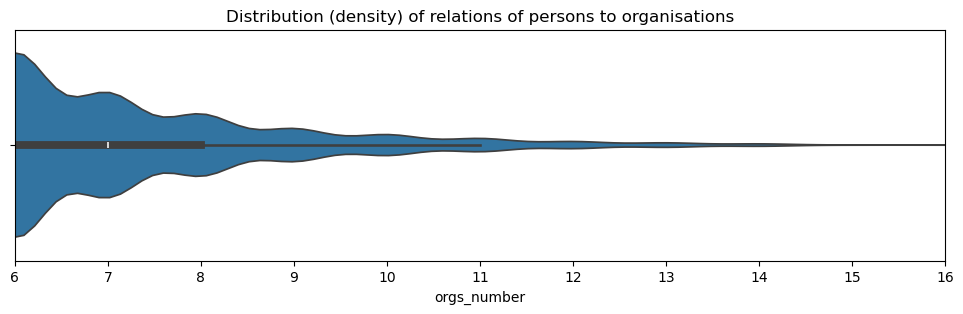

In [100]:
# Plot the distribution of eigenvector density

df=gr_memb[gr_memb.orgs_number>5]

min_val = df.orgs_number.min()
max_val = df.orgs_number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.orgs_number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

## Most frequent organisations as relations

Organisations where memberships' relationship happen are different from those where people are educated and are employed, as we can see if we compare the tables below.

We therefore just join educational institutions and employers

In [101]:
### Study
gbe_edu.head(10)

,organisation_label,number
0,Harvard University,3317
1,Massachusetts Institute of Technology,2392
2,University of Cambridge,2197
3,"University of California, Berkeley",1856
4,California Institute of Technology,1739
5,MSU Faculty of Physics,1337
6,Lomonosov Moscow State University,1279
7,Princeton University,1238
8,University of Göttingen,1126
9,University of Chicago,1003


In [102]:
### Employment
gbe_empl.head(10)

,organisation_label,number
0,Harvard University,9192
1,Massachusetts Institute of Technology,7153
2,"University of California, Berkeley",6824
3,California Institute of Technology,4206
4,Princeton University,3973
5,Lomonosov Moscow State University,3801
6,Leiden University,3348
7,University of Chicago,2896
8,University of Cambridge,2827
9,University of Göttingen,2415


In [103]:
### Join first hundred organisation for education and employment

gb_organ_of_rel=pd.merge(left=gbe_edu, on='organisation_label', right=gbe_empl,
                suffixes=('_rel_edu', '_rel_empl'), how='outer')
gb_organ_of_rel[['number_rel_edu','number_rel_empl']]=gb_organ_of_rel[['number_rel_edu','number_rel_empl']].fillna(0).astype('int')
print(len(gb_organ_of_rel))
gb_organ_of_rel.head()

136


,organisation_label,number_rel_edu,number_rel_empl
0,Adam Mickiewicz University in Poznań,30,0
1,Bauman Moscow State Technical University,38,0
2,Bell Labs,0,1230
3,Brookhaven National Laboratory,0,192
4,CERN,0,1270


In [104]:
### Inspect most frequent organisations, order by study
gb_organ_of_rel.sort_values(by='number_rel_edu', ascending=False).iloc[:10]

,organisation_label,number_rel_edu,number_rel_empl
22,Harvard University,3317,9192
44,Massachusetts Institute of Technology,2392,7153
94,University of Cambridge,2197,2827
89,"University of California, Berkeley",1856,6824
5,California Institute of Technology,1739,4206
43,MSU Faculty of Physics,1337,0
38,Lomonosov Moscow State University,1279,3801
61,Princeton University,1238,3973
101,University of Göttingen,1126,2415
95,University of Chicago,1003,2896


In [105]:
### Inspect most frequent organisations, order by employer
# Note the difference, e.g. the MSU Faculty of Physcs has no employee ... 
# There should be a bias in the data (not yet verified)
# See also CERN and Bell Labs
gb_organ_of_rel.sort_values(by='number_rel_empl', ascending=False).iloc[:30]


,organisation_label,number_rel_edu,number_rel_empl
22,Harvard University,3317,9192
44,Massachusetts Institute of Technology,2392,7153
89,"University of California, Berkeley",1856,6824
5,California Institute of Technology,1739,4206
61,Princeton University,1238,3973
38,Lomonosov Moscow State University,1279,3801
36,Leiden University,225,3348
95,University of Chicago,1003,2896
94,University of Cambridge,2197,2827
101,University of Göttingen,1126,2415


In [106]:
### Membership
# These are totally different institution with regard to the former ones
gbe_memb.head(10)

,organisation_label,number
0,International Astronomical Union,260033
1,National Academy of Sciences,237685
2,American Academy of Arts and Sciences,233831
3,Royal Society,88610
4,Russian Academy of Sciences,68782
5,Academia Europaea,56059
6,German Academy of Sciences Leopoldina,49414
7,American Physical Society,30390
8,Academy of Sciences of the USSR,24223
9,American Philosophical Society,23826


## Merge the three networks: where do the encounters happen?

We merge the three tables of relations (education, employment, membership) and observe where encounters happen.

In [115]:
### Join educational and employment persons' pairs
# All relationships are kept, left and right join -> outer
network=pd.merge(gr_edu, gr_empl, on=['person_uri_x', 'person_uri_y', 'per_activ_x', 'per_activ_y'],
                 how='outer', suffixes=('_edu', '_empl'), indicator=True)
network.rename(columns={'_merge': 'merge_1'}, inplace=True)

In [116]:
print('Number of edu+empl pairs:',len(network))
network.sort_values(by='orgs_number_edu', ascending=False).head(2)

Number of edu+empl pairs: 132309


,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,orgs_uris_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_uris_empl,merge_1
63077,http://www.wikidata.org/entity/Q181369,http://www.wikidata.org/entity/Q183679,National Southwestern Associated University|Na...,5.0,http://www.wikidata.org/entity/Q519556|http://...,1951-1975,1951-1975,NaN,NaN,NaN,left_only
129137,http://www.wikidata.org/entity/Q742536,http://www.wikidata.org/entity/Q9095,University of Edinburgh|Edinburgh Academy|Univ...,4.0,http://www.wikidata.org/entity/Q160302|http://...,1876-1900,1876-1900,NaN,NaN,NaN,left_only


In [117]:
### Join to network the membership persons' pairs
# All relationships are kept, left and right join -> outer
network=pd.merge(network, gr_memb, on=['person_uri_x', 'person_uri_y', 'per_activ_x', 'per_activ_y' ],
                 how='outer', suffixes=('', '_memb'), indicator=True)
network.rename(columns={'orgs_labels': 'orgs_labels_memb','orgs_number': 'orgs_number_memb','organisation_uri': 'orgs_uris_memb'}, inplace=True)

In [118]:
network['orgs_number_edu'].fillna(0, inplace=True)
network['orgs_number_empl'].fillna(0, inplace=True)
network['orgs_number_memb'].fillna(0, inplace=True)
network['orgs_number_memb']=network['orgs_number_memb'].astype(int)
network['orgs_number_edu']=network['orgs_number_edu'].astype(int)
network['orgs_number_empl']=network['orgs_number_empl'].astype(int)
network=network[['person_uri_x', 'person_uri_y', 'orgs_labels_edu', 'orgs_number_edu', 'per_activ_x', 'per_activ_y', 'orgs_labels_empl', 'orgs_number_empl', 'orgs_labels_memb', 'orgs_number_memb']]

In [119]:
print('Number of edu+empl+memb pairs:',len(network))
network.iloc[550:555]

Number of edu+empl+memb pairs: 1075467


,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb
550,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q712375,NaN,0,1926-1950,1951-1975,California Institute of Technology,1,National Academy of Sciences|American Philosop...,2
551,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q714440,NaN,0,1926-1950,1926-1950,California Institute of Technology,1,National Academy of Sciences|American Philosop...,2
552,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q714462,NaN,0,1926-1950,1926-1950,NaN,0,National Academy of Sciences,1
553,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q717421,NaN,0,1926-1950,1951-1975,California Institute of Technology,1,National Academy of Sciences|American Philosop...,2
554,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q719033,NaN,0,1926-1950,1901-1925,NaN,0,National Academy of Sciences,1


In [120]:
### create field with sum of edu and empl
network['sum_edu_empl']=network['orgs_number_edu']+network['orgs_number_empl']

In [121]:
### create field with sum of all values
network['sum_all_rel']=network['orgs_number_edu']+network['orgs_number_empl']+network['orgs_number_memb']

#### Add persons' labels

In [125]:
network=pd.merge(left=network,right=df_p[['person_uri','labelPer','birthYear']], left_on='person_uri_x', right_on='person_uri')

In [126]:
network.drop(columns=['person_uri'], inplace=True)

In [127]:
network=pd.merge(left=network,right=df_p[['person_uri','labelPer','birthYear']], left_on='person_uri_y', right_on='person_uri', suffixes=('_x1', '_y'))


In [128]:
network.head(2)

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb,sum_edu_empl,sum_all_rel,labelPer_x1,birthYear_x1,person_uri,labelPer_y,birthYear_y
0,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q100216,NaN,0,1951-1975,1976-2000,NaN,0,German Academy of Sciences Leopoldina,1,0,1,Hans Elsässer,1929,http://www.wikidata.org/entity/Q100216,Willi Kalender,1949
1,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q102226864,NaN,0,1951-1975,1951-1975,NaN,0,German Academy of Sciences Leopoldina,1,0,1,Hans Elsässer,1929,http://www.wikidata.org/entity/Q102226864,Werner Känzig,1922


In [129]:
network.rename(columns={'labelPer_x1': 'labelPer_x','birthYear_x1': 'birthYear_x'}, inplace=True)

In [130]:
network.drop(columns=['person_uri'], inplace=True)

In [131]:
network.head(2)

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb,sum_edu_empl,sum_all_rel,labelPer_x,birthYear_x,labelPer_y,birthYear_y
0,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q100216,NaN,0,1951-1975,1976-2000,NaN,0,German Academy of Sciences Leopoldina,1,0,1,Hans Elsässer,1929,Willi Kalender,1949
1,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q102226864,NaN,0,1951-1975,1951-1975,NaN,0,German Academy of Sciences Leopoldina,1,0,1,Hans Elsässer,1929,Werner Känzig,1922


In [132]:
### Change columns order
network=network[['labelPer_x',
  'labelPer_y',
  'birthYear_x','birthYear_y',
'per_activ_x', 'per_activ_y',
 'sum_edu_empl', ### study and employment relationshipa
 'sum_all_rel', ### all the relationships
 'orgs_number_edu',  'orgs_labels_edu', 
 'orgs_number_empl', 'orgs_labels_empl',
 'orgs_number_memb', 'orgs_labels_memb',
 'person_uri_x', 'person_uri_y'
   ]]

In [139]:
### SQL Queries


# order by max sum of edu and empl relations
query_1="""
    SELECT *
    FROM network
    ORDER BY sum_edu_empl DESC
    LIMIT 5
"""


# order by max sum of all relations
query_2="""
    SELECT * 
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
    ORDER BY sum_all_rel DESC
    --OFFSET 500
    LIMIT 10
"""

# order by max sum of all relations
query_2_count="""
    SELECT COUNT(*) as number  -- 3922
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
"""

# order by max  edu and empl relations
query_3="""
    SELECT *
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
    ORDER BY orgs_number_empl DESC, orgs_number_edu DESC
    --OFFSET 500
    LIMIT 10
"""

In [140]:
duckdb.query(query_2).to_df()

,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
0,Rudolf Clausius,Hermann von Helmholtz,1822,1821,1851-1875,1851-1875,3,17,1,Frederick William University Berlin,2,University of Bonn|Frederick William Universit...,14,Accademia Nazionale delle Scienze detta dei XL...,http://www.wikidata.org/entity/Q30693,http://www.wikidata.org/entity/Q60024
1,Peter Debye,Albert Einstein,1884,1879,1926-1950,1901-1925,4,15,1,ETH Zurich,3,ETH Zurich|Humboldt-Universität zu Berlin|Univ...,11,Russian Academy of Sciences|Bavarian Academy o...,http://www.wikidata.org/entity/Q103835,http://www.wikidata.org/entity/Q937
2,Peter Debye,Max von Laue,1884,1879,1926-1950,1901-1925,4,14,1,Ludwig-Maximilians-Universität München,3,Humboldt-Universität zu Berlin|University of Z...,10,Pontifical Academy of Sciences|Bavarian Academ...,http://www.wikidata.org/entity/Q103835,http://www.wikidata.org/entity/Q57067
3,Max von Laue,Max Born,1879,1882,1901-1925,1926-1950,4,14,2,University of Göttingen|University of Zurich,2,Humboldt-Universität zu Berlin|Goethe Universi...,10,Göttingen Eighteen|German Academy of Sciences ...,http://www.wikidata.org/entity/Q57067,http://www.wikidata.org/entity/Q58978
4,Max von Laue,Albert Einstein,1879,1879,1901-1925,1901-1925,3,14,1,University of Zurich,2,Humboldt-Universität zu Berlin|University of Z...,11,American Philosophical Society|Bavarian Academ...,http://www.wikidata.org/entity/Q57067,http://www.wikidata.org/entity/Q937
5,George Howard Darwin,"John Strutt, 3rd Baron Rayleigh",1845,1842,1876-1900,1876-1900,3,14,2,Trinity College|University of Cambridge,1,University of Cambridge,11,American Academy of Arts and Sciences|Saint Pe...,http://www.wikidata.org/entity/Q325016,http://www.wikidata.org/entity/Q83297
6,François Arago,Siméon Denis Poisson,1786,1781,1826-1850,1826-1850,3,13,1,École polytechnique,2,Bureau des Longitudes|École polytechnique,10,American Academy of Arts and Sciences|Saint Pe...,http://www.wikidata.org/entity/Q154353,http://www.wikidata.org/entity/Q190772
7,Geoffrey Ingram Taylor,Niels Bohr,1886,1885,1926-1950,1926-1950,3,12,2,University of Cambridge|Trinity College,1,University of Cambridge,9,Russian Academy of Sciences|Polish Academy of ...,http://www.wikidata.org/entity/Q699541,http://www.wikidata.org/entity/Q7085
8,Arthur Eddington,Niels Bohr,1882,1885,1926-1950,1926-1950,3,12,2,Trinity College|University of Cambridge,1,University of Cambridge,9,Royal Society|Royal Swedish Academy of Science...,http://www.wikidata.org/entity/Q215022,http://www.wikidata.org/entity/Q7085
9,James Franck,Max von Laue,1882,1879,1926-1950,1901-1925,2,12,1,Humboldt-Universität zu Berlin,1,Humboldt-Universität zu Berlin,10,American Philosophical Society|German Academy ...,http://www.wikidata.org/entity/Q57066,http://www.wikidata.org/entity/Q57067


In [141]:
print('Tot:', len(network), 'Edu:', len
      (gr_edu), ', Empl:', len(gr_empl), ', Memb:', len(gr_memb))

Tot: 1075467 Edu: 33071 , Empl: 103160 , Memb: 997706


### Store the network on the disk

DO NOT COMMIT THIS FILE IF NOT ADDED *.pkl  TO .gitignore

In [ ]:
### BEWARE: add all pickle files to the .gitignore file with this entry . *.pkl

### DO NOT COMMIT THIS FILE IF NOT ADDED *.pkl  TO .gitignore

file_address='da_data/da6-networks.pkl'
network.to_pickle(file_address)

## Correlations

We could wonder if the fact of studying together, or working together would lead to be member of the same organisations.

Given the large amount of people having just one or to relation, we only consider people having at least four relationships.

We use here ranking correlation given that we are counting relations

Surprisingly:
* there is some weak positive relation between studying and working together
* but there is a stronger negative correlation between studying or working together and being member of same organisations 


In [7]:
### ONLY EXECUTE if you need to restart the notebook from the stored network

file_address='da_data/da6-networks.pkl'
network=pd.read_pickle(file_address)
print(len(network))
network.iloc[:3]

1075467


,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
0,Hans Elsässer,Willi Kalender,1929,1949,1951-1975,1976-2000,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q100216
1,Hans Elsässer,Werner Känzig,1929,1922,1951-1975,1951-1975,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q102226864
2,Hans Elsässer,Aage Bohr,1929,1922,1951-1975,1951-1975,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q103854


In [ ]:
### Inspect cooccurrence of pairs, before analysing correlations

# We observe that we have quite sparse data in the network !

print('Total number of relationships:',len(network))
print('Edu', len(network[(network.orgs_number_edu>0)]))
print('Empl', len(network[(network.orgs_number_empl>0)]))
print('Memb', len(network[(network.orgs_number_memb>0)]))
print('Study and work together',len(network[(network.orgs_number_edu>0) & (network.orgs_number_empl>0)]))
print('Study and membership together', len(network[(network.orgs_number_edu>0) & (network.orgs_number_memb>0) ]))
print('Work and membership together',len(network[ (network.orgs_number_empl>0) & (network.orgs_number_memb>0) ]))
print('All three phases together',len(network[(network.orgs_number_edu>0) & (network.orgs_number_empl>0) & (network.orgs_number_memb>0) ]))

Total number of relationships: 1075467
Edu 33071
Empl 103160
Memb 997706
Study and work together 3922
Study and membership together 15248
Work and membership together 41890
All three phases together 2590


In [8]:
### We only consider in the distribution more than three
df=network[network.sum_all_rel>5].copy(deep=True)
print(len(df))
print(df.sum_all_rel.describe())

2847
count    2847.000000
mean        7.271865
std         1.692816
min         6.000000
25%         6.000000
50%         7.000000
75%         8.000000
max        17.000000
Name: sum_all_rel, dtype: float64


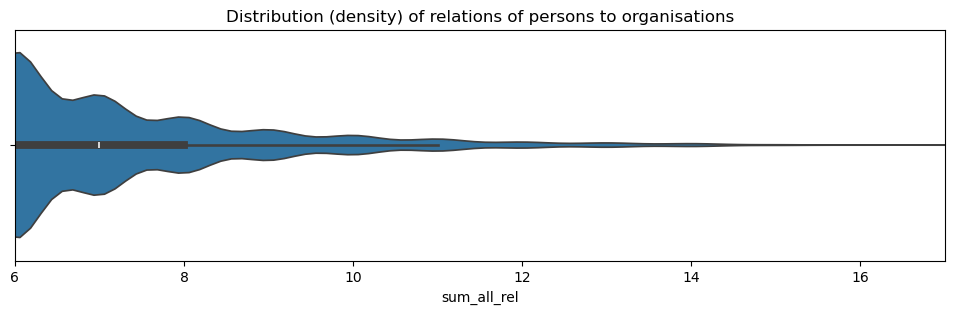

In [9]:

### Plot the distribution of the total number of relations
# where there are more than 3 relations
min_val = df.sum_all_rel.min()
max_val = df.sum_all_rel.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.sum_all_rel, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

### Measure the correlations

#### Relationships in studies and in employment

We only can use rank correlation given these are counts. 

Also, most educational relations have count: 1 - so the correlation does not really make sense

In [10]:
predictor_name='orgs_number_edu' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_empl'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis: on ranking because these are counts
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: 0.3205 (p-value: 0.0000)


#### Relationships in studies and in membership

In [11]:

predictor_name='orgs_number_edu' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_memb'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis: on ranking because these are counts
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.2952 (p-value: 0.0000)


#### Relationships in employment and in membership

In [12]:

predictor_name='orgs_number_empl' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_memb'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.4825 (p-value: 0.0000)


### Represent the correlations

In [14]:
df=df[['sum_all_rel', 'orgs_number_edu', 
       'orgs_number_empl', 'orgs_number_memb']].\
              sort_values(by=['orgs_number_memb'])
df.reset_index(inplace=True, drop=True)
df.head()

,sum_all_rel,orgs_number_edu,orgs_number_empl,orgs_number_memb
0,6,2,3,1
1,6,1,4,1
2,6,1,4,1
3,6,1,3,2
4,6,0,4,2


In [15]:
# Smooth with gliding mean

# Ensure data is sorted by index (and value)

df['smoothed_memb'] = df['orgs_number_memb'].rolling(window=100, min_periods=1).mean()
df['smoothed_empl'] = df['orgs_number_empl'].rolling(window=100, min_periods=5).mean()
df['smoothed_edu'] = df['orgs_number_edu'].rolling(window=100, min_periods=1).mean()
df['smoothed_all'] = df['sum_all_rel'].rolling(window=100, min_periods=1).mean()



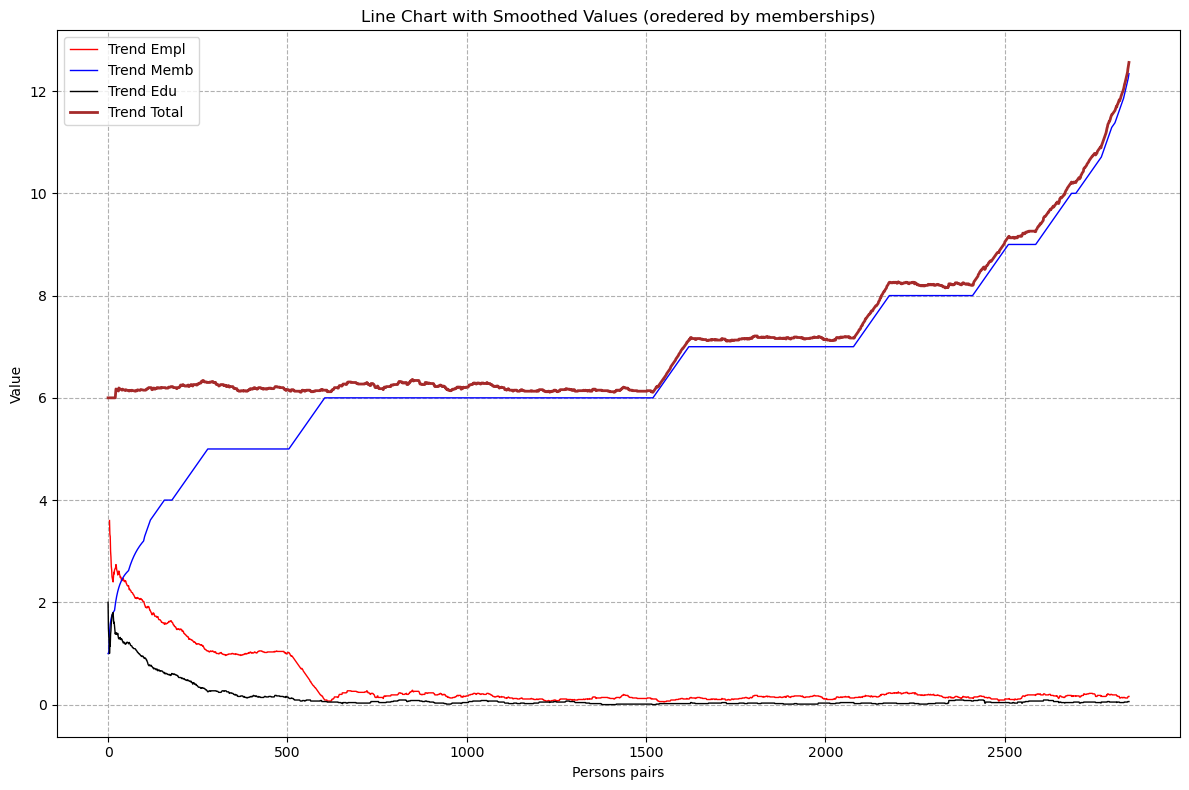

In [19]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(df['smoothed_empl'], linestyle='-', color='red', linewidth=1, label='Trend Empl')
ax.plot(df['smoothed_memb'],  linestyle='-', color='blue', linewidth=1, label='Trend Memb')
ax.plot(df['smoothed_edu'],  linestyle='-', color='black', linewidth=1, label='Trend Edu')
ax.plot(df['smoothed_all'],  linestyle='-', color='brown', linewidth=2, label='Trend Total')

ax.set_xlabel('Persons pairs')
ax.set_ylabel('Value')
ax.set_title('Line Chart with Smoothed Values (oredered by memberships)')
ax.grid(True, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()